<a href="https://colab.research.google.com/github/RaniaChaudhry511/Unsupervised-Learning/blob/main/K_means_clustering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INTRODUCTION

Mall Customer Segmentation using K-Means Clustering

In this project, we are applying K-Means Clustering (an unsupervised machine learning algorithm) on the Mall Customer dataset from Kaggle. The goal is to segment customers into distinct groups based on their Annual Income and Spending Score — without any predefined labels. This helps mall management understand customer behavior and design better marketing strategies for each customer group.


#step 1: DATA LOADING AND UNDERSTANDING

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#STEP 2: DATA CLEANING

AS THERE ARE NO MISSING VALUES OR DUPLICATES SO WE DONT NEED DO TO SO MUCH CLEANING

In [ ]:
df.drop('CustomerID', axis=1, inplace=True)

In [ ]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col} outliers: {len(outliers)}')

Age outliers: 0
Annual Income (k$) outliers: 2
Spending Score (1-100) outliers: 0


Note: During outlier detection, 2 outliers were found in the Annual Income column. Since the dataset contains 200 rows, these 2 outliers are very minimal and will not significantly affect the K-Means clustering results. Therefore, we decided to keep them as they are and move forward.


#STEP 3: EDA

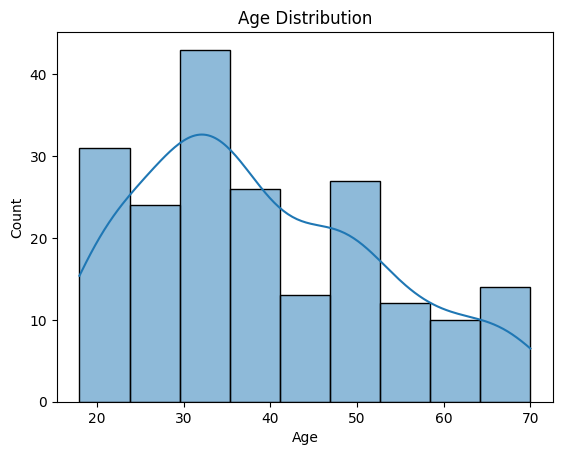

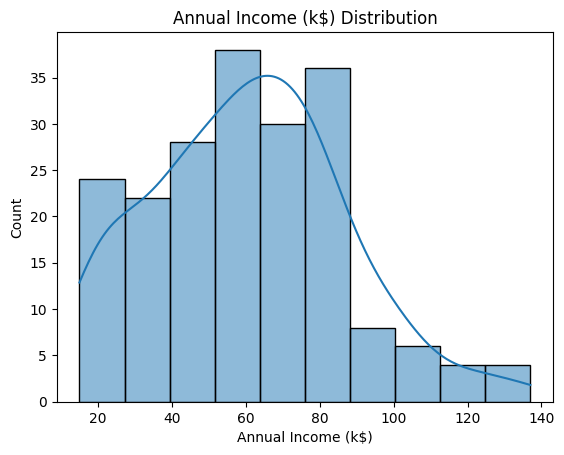

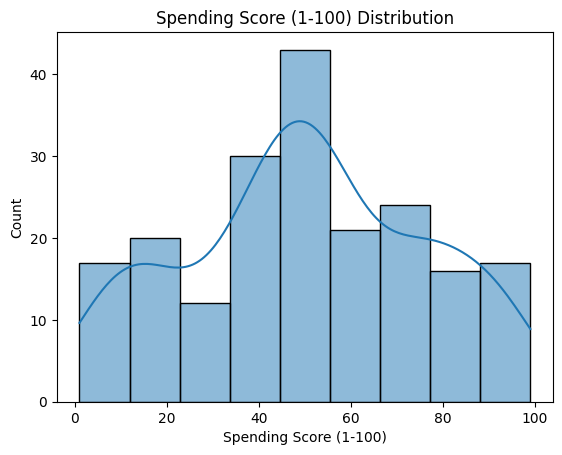

In [ ]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

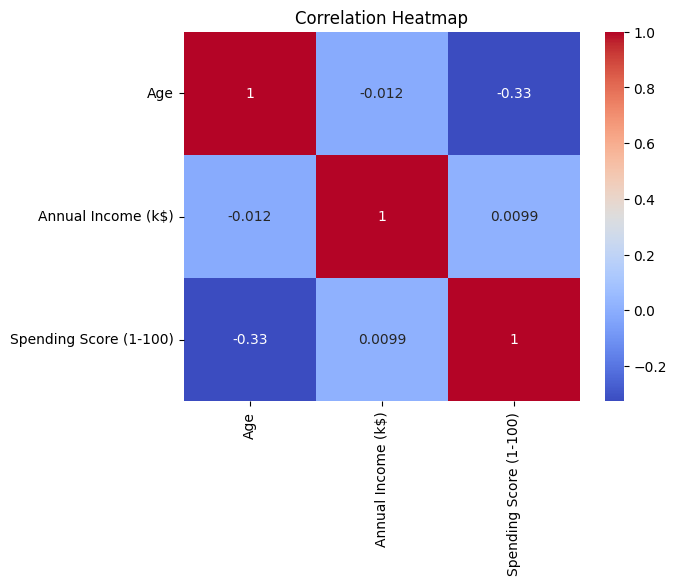

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df.groupby('Gender')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


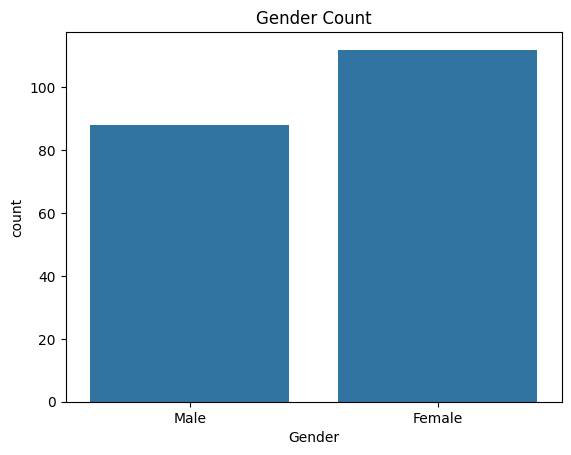

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Count')
plt.show()

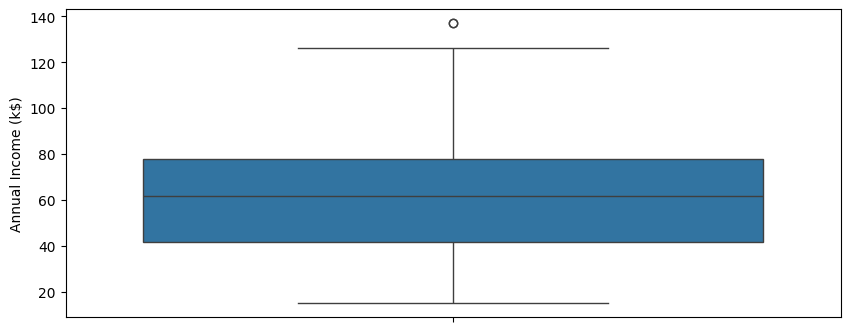

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(df['Annual Income (k$)'])
plt.show()

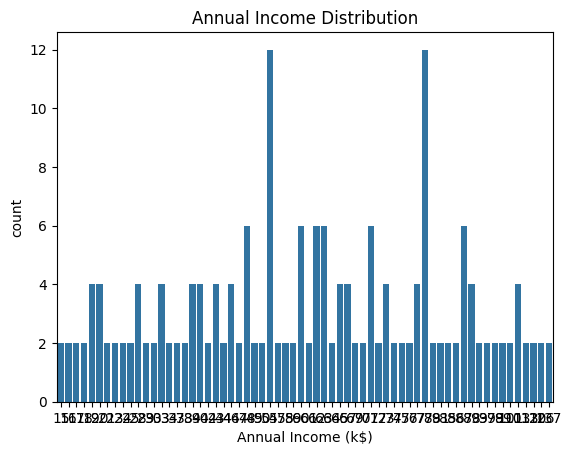

In [ ]:
sns.countplot(x='Annual Income (k$)', data=df)
plt.title('Annual Income Distribution')
plt.show()

#STEP 4: FEATURE ENGINEERING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Annual Income (k$)', 'Spending Score (1-100)']])

#STEP 5: MODEL SELECTION

Note: In Model Selection we use the Elbow Method to find the optimal number of clusters (K). We plot WCSS (Within Cluster Sum of Squares) against different values of K. The point where the graph bends like an elbow is our optimal K. In this dataset K=5 is the best choice.


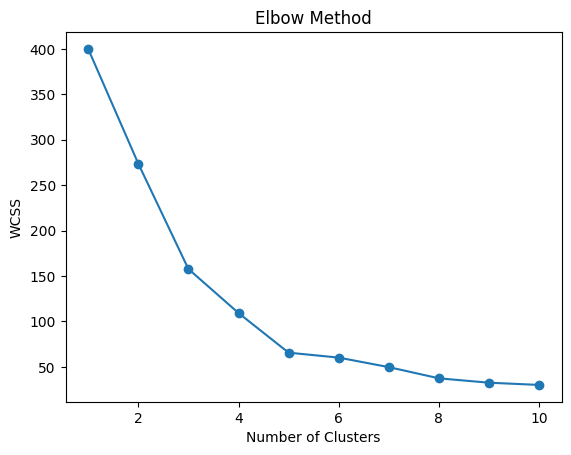

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f'K={i}, Silhouette Score: {score:.4f}')

K=2, Silhouette Score: 0.3973
K=3, Silhouette Score: 0.4666
K=4, Silhouette Score: 0.4943
K=5, Silhouette Score: 0.5547
K=6, Silhouette Score: 0.5138
K=7, Silhouette Score: 0.5020
K=8, Silhouette Score: 0.4550
K=9, Silhouette Score: 0.4567
K=10, Silhouette Score: 0.4448


Note: From the Silhouette Score results, K=5 has the highest score of 0.5547 which means clusters are well separated and dense. Therefore K=5 is confirmed as our optimal number of clusters. This also matches our Elbow Method result.


#STEP 6: MODEL TRAINING

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_data)
labels = kmeans.labels_
df['Cluster'] = labels
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


Note: We trained our K-Means model with K=5 and fitted it on our scaled data. The model assigned each customer a cluster label (0 to 4) which is added as a new column in our dataframe. This means each customer now belongs to a specific group based on their Annual Income and Spending Score.


#STEP 7: CLUSTER/PATTERN ANALYSIS

Cluster Analysis

In this step we analyze each cluster to understand what type of customers belong to each group. We use groupby to calculate the mean values of each feature for every cluster.


In [ ]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


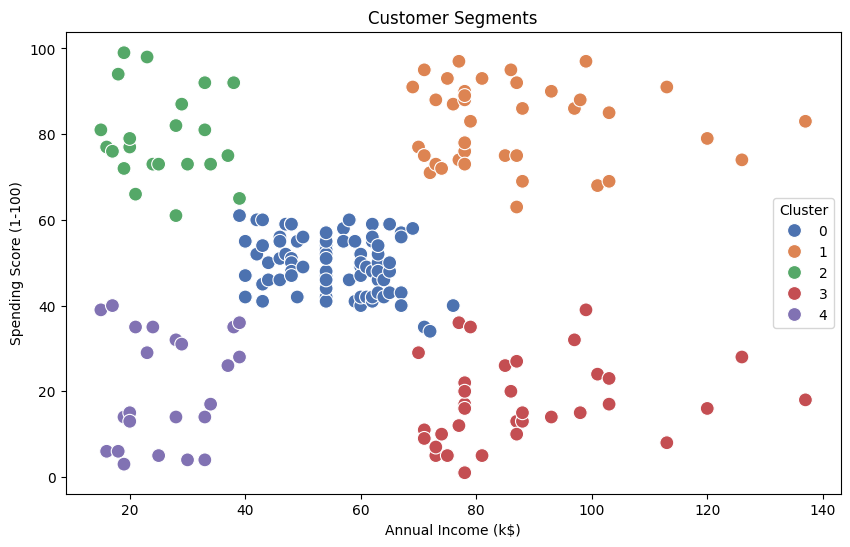

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Customer Segments")
plt.show()

Note: Based on the mean values of Annual Income and Spending Score we can identify 5 types of customers. Cluster 0 has medium income and medium spending so they are Average Customers. Cluster 1 has high income and high spending so they are VIP Customers. Cluster 2 has low income but high spending so they are Impulsive Buyers. Cluster 3 has high income but low spending so they are Careful Rich customers. Cluster 4 has low income and low spending so they are Budget Savers.


#STEP 8 MODEL EVALUATION

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print('Silhouette Score:', silhouette_score(scaled_data, labels))
print('Davies Bouldin Score:', davies_bouldin_score(scaled_data, labels))
print('Calinski Harabasz Score:', calinski_harabasz_score(scaled_data, labels))

Silhouette Score: 0.5546571631111091
Davies Bouldin Score: 0.5722356162263352
Calinski Harabasz Score: 248.64932001536357


Note: Our model evaluation results are very good. Silhouette Score of 0.5547 is close to 1 which means clusters are well separated. Davies Bouldin Score of 0.5722 is close to 0 which means clusters are distinct from each other. Calinski Harabasz Score of 248.65 is high which means clusters are dense and well defined. Overall our K-Means model with K=5 has performed very well on this dataset.



#STEP 9: HYPERPARAMETER TUNNING

In [ ]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'n_clusters': [3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [100, 300, 500],
    'n_init': [5, 10]
}

best_score = -1
best_params = {}

for params in ParameterGrid(param_grid):
    kmeans = KMeans(random_state=42, **params)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    if score > best_score:
        best_score = score
        best_params = params

print('Best Score:', best_score)
print('Best Params:', best_params)

Best Score: 0.5546571631111091
Best Params: {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 5, 'n_init': 5}


Note: After Hyperparameter Tuning our best Silhouette Score is 0.5547 with K=5, init=k-means++, max_iter=100 and n_init=5. This confirms that our original model was already optimal. K-means++ initialization gives better results than random initialization as it selects initial centroids more smartly.


#STEP 10: PIPELINE BUILDING

In this step we combine all our preprocessing and model steps into a single pipeline. This makes our code cleaner and easier to use on new data in the future.


Note: We build a pipeline using StandardScaler and KMeans with our best parameters. Instead of applying scaling and model separately, pipeline does everything in one step automatically.


In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, init='k-means++', max_iter=100, n_init=5, random_state=42))
])

pipeline.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans',
                 KMeans(max_iter=100, n_clusters=5, n_init=5,
                        random_state=42))])


Note: Our pipeline is successfully built with StandardScaler and KMeans as steps. Pipeline first scales the data automatically and then applies KMeans clustering. This makes it easy to use on any new data in the future without applying steps separately.


#FINAL CONCLUSION

Conclusion

In this project we performed Customer Segmentation on the Mall Customers dataset using K-Means Clustering. We successfully divided 200 customers into 5 distinct groups based on their Annual Income and Spending Score. Our model achieved a Silhouette Score of 0.5547 which confirms that the clusters are well separated and meaningful. This segmentation can help mall management to target each customer group with different marketing strategies and improve their business decisions.
